# Dimensionality Reduction

In this exercise, we will use principal component analysis to perform dimensionality reduction on our dataset. Recall that the `netml` library has mechanisms to extract a wide range of statistics from traffic flows. We will start with those (an N-dimensional feature set), and then use principal component analysis to reduce the dimensionality of the data.

In [2]:
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP

import pandas as pd

## Load the Packet Capture Files

Load the Log4j and HTTP packet capture files and extract features from the flows. You can feel free to compute features manually, although it will likely be more convenient at this point to use the `netML` library.

In [5]:
# Load both captures. flow_ptks_thres=2 drops single-packet flows,
# which have no inter-arrival times and produce empty feature vectors.
hpcap = PCAP('data/http.pcap', flow_ptks_thres=2)
lpcap = PCAP('data/log4j.pcap', flow_ptks_thres=2)

## Convert the Packet Capture Into Flows

Find the function in `netml` that converts the pcap file into flows. Examing the resulting data structure. What does it contain?

In [6]:
hpcap.pcap2flows()
lpcap.pcap2flows()

# Each flow is a (5-tuple, packets) pair
key, packets = hpcap.flows[0]
print(type(hpcap.flows))
print(key)
print(len(packets), 'packets; first:', packets[0].summary())

<class 'list'>
('192.168.1.58', '35.186.224.43', 57256, 443, 6)
4 packets; first: Ether / IP / TCP 192.168.1.58:57256 > 35.186.224.43:https PA / Raw


`pcap2flows()` populates `pcap.flows`, a **list** with one entry per flow. Each entry is a tuple of:

1. the flow key, a 5-tuple `(src IP, dst IP, src port, dst port, protocol)`, and
2. the list of Scapy packets belonging to that flow.

Flows with fewer than `flow_ptks_thres` packets are discarded.

## Explore the Flows

How many flows are in each of these pcaps? (Use the `netml` library output to determine the size of each data structure.)

In [7]:
print(f'http.pcap  -> {len(hpcap.flows):>5} flows')
print(f'log4j.pcap -> {len(lpcap.flows):>5} flows')

http.pcap  ->   291 flows
log4j.pcap ->  4795 flows


Next, compute the 12 `STATS` features for each flow and combine both captures into a single labeled dataset (`0` = HTTP, `1` = Log4j).

In [8]:
hpcap.flow2features('STATS', fft=False, header=False)
lpcap.flow2features('STATS', fft=False, header=False)

stats_cols = ['duration', 'packets per second', 'bytes per second',
              'mean', 'standard deviation', '25', 'median', '75',
              'minimum', 'maximum', 'packets', 'bytes']

hd = pd.DataFrame(hpcap.features, columns=stats_cols)
hd['label'] = 0
ld = pd.DataFrame(lpcap.features, columns=stats_cols)
ld['label'] = 1

df = pd.concat([hd, ld], ignore_index=True)
X = df[stats_cols].values
y = df['label'].values

print('http features: ', hd.shape)
print('log4j features:', ld.shape)
df['label'].value_counts()

http features:  (291, 13)
log4j features: (4795, 13)


label
1    4795
0     291
Name: count, dtype: int64

The dataset is heavily imbalanced: there are far more Log4j flows than HTTP flows. Keep this in mind when evaluating accuracy (and it is why we use `class_weight='balanced'` for the random forest below).

## Try Your Data on a Tree-Based Model

You should now have data that can be input into a model with scikit-learn. Import the scikit-learn package (`sklearn`) and a classification model of your choice to test that you can train your model with the above data. 

Hint: The function you want to call is `fit`.

Before applying dimensionality reduction, we can first build on our understanding of classifiers from past notebooks to see which features may be most important. 

Let's try training a model first with a **Decision Tree**, then with a RandomForest classifier, which gives us nice ways of exploring feature importance.

### Decision Tree

Train a decision tree below.

### Visualize the Resulting Model

Below is an example showing how the resulting decision tree can be visualized. We kept the number of features small above to make visualization quick. You may need to install some dependencies (pydotplus, plus the graphviz executable, to get this cell to run.

To install graphviz on a Mac, for example, you can use a tool like Homebrew (e.g., brew install graphviz).

In [10]:
from sklearn import tree
import pydotplus
from IPython.display import Image

labels = ['duration', 'packets per second', 
          'bytes per second', 
          'mean', 'standard deviation', 
          '25', 'median', '75', 
          'minimum', 'maximum',
          'packets','bytes']

dot_data = tree.export_graphviz(dt, out_file=None, feature_names=labels)

graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

NameError: name 'dt' is not defined

### Evaluate the Model

We can look at the accuracy of this simple model using a K-Fold cross validation and accuracy score.

## Random Forest Classifiers
Random forest improves on a decision tree classifier using an ensemble learning method called bagging. In a random forest, 

1. many decision trees are trained. Each tree receives a boostrapped sample of observations, and
2. each node only considers a subset of the features when determining the best split.

The balanced mode, which we use below, uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y)).

### Train a Random Forest Classifier

Train a random forest classifier using the same approach as you used for the decision tree.

### Evaluate Your Classifier

Evaluate your random forest classifier using the same evaluation method as for the decision tree.  Does accuracy improve?

## Feature Importance

One of the powerful aspects of a random forest classifier is that it is easy to plot and understand feature importance. The feature_importances_ data structure maintains these relative feature importance values, which we can plot and visualize.

## Dimensionality Reduction

One way to reduce the dimensionality of a dataset is with a technique called principal components analysis (PCA). PCA is a linear transformation that maps the points into a space where the lower dimensions are orthogonal and also capture the highest variance in the dataset.

So, the first principal component (PC1) is a vector that is oriented in the direction that captures the highest variance in the dataset. You can think of this as the single dimension that has the most information in the dataset. PC2 captures the next highest variance, in the direction that is orthogonal to PC2, and so forth.

There are many applications of PCA, but one application is the visualization of a high-dimension dataset, since PCA is just a transformation of the data that does not inherently lose information. When we only project into the top two dimensions, some information is lost (whatever is in the lower principal compoenents), but we can visualize the data in terms of the two dimensions that capture the most "information" (i.e., variance) in the dataset.

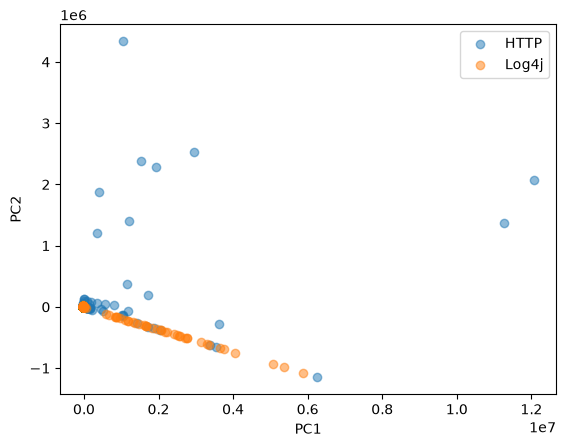

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Project the 12 STATS features onto the top two principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

for label, name in [(0, 'HTTP'), (1, 'Log4j')]:
    plt.scatter(X_pca[y == label, 0], X_pca[y == label, 1], alpha=0.5, label=name)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend();

### Understanding Explained Variance

The first principal components will capture msot of the variance. We can look at the explained variance ratio to understand how much variance each of those principal components captures, which will give us a sense of where we might be able to cut off this data, particularly if we look at cumulative explained variance.

In [15]:
pca.explained_variance_ratio_

array([0.91489261, 0.08507621])

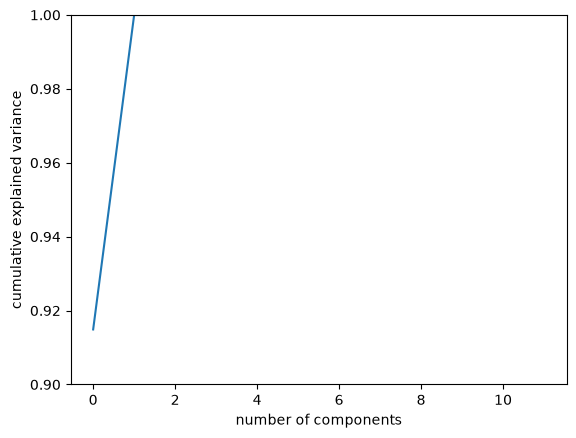

In [24]:
pca = PCA(n_components=12)
pca.fit(X)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.ylim([0.9,1])
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

### Understanding the Top Principal Components

If we look at the top principal component, we can also see that it is a linear combination of our original features. On the raw data, it is dominated almost entirely by `bytes per second` (with a smaller contribution from `bytes`), simply because those features have by far the largest numeric range.

In [17]:
pca.components_[0]


array([-1.11131659e-06,  7.11715178e-03,  9.83734774e-01,  8.89456135e-05,
       -2.89616810e-07,  1.03849723e-04,  1.05013360e-04,  1.02492726e-04,
        3.33622642e-06,  5.35074914e-05,  1.23282170e-04,  1.79485885e-01])

In [18]:
# Sort in descending order
indices = np.argsort(pca.components_[0])[::-1]

# Sort the labels in a corresponding fashion
names = [labels[i] for i in indices]
names

['bytes per second',
 'bytes',
 'packets per second',
 'packets',
 'median',
 '25',
 '75',
 'mean',
 'maximum',
 'minimum',
 'standard deviation',
 'duration']

### Scaling the Features Before PCA

PCA finds the directions of greatest variance, so it is sensitive to the units each feature is measured in. Our features are on very different scales: `bytes per second` has a standard deviation in the hundreds of thousands, while `duration` is in the single digits. On the raw data, PC1 is essentially just the `bytes per second` column, which is why a single component appears to explain over 90% of the variance.

Standardizing each feature to zero mean and unit variance (`StandardScaler`) puts all features on an equal footing before PCA.

In [30]:
# Standard deviation of each feature, in its original units
df[stats_cols].std().sort_values(ascending=False)

bytes per second      354507.222769
bytes                 125778.945593
packets per second      3583.335934
maximum                  268.515693
75                       171.522762
median                   130.244398
mean                     119.427754
25                       104.468380
standard deviation       104.282694
packets                   87.279442
minimum                   18.856157
duration                   6.264201
dtype: float64

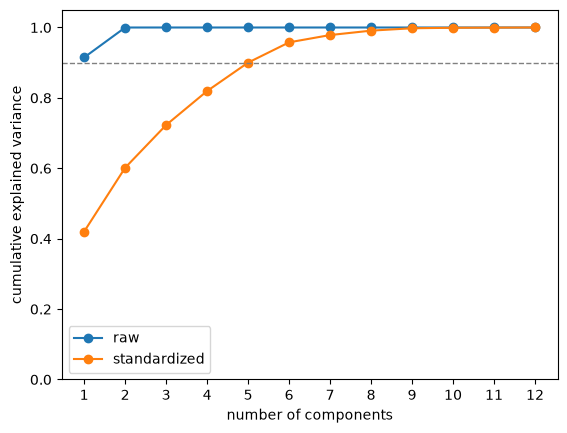

In [31]:
from sklearn.preprocessing import StandardScaler

# Rescale every feature to mean 0 and standard deviation 1
X_scaled = StandardScaler().fit_transform(X)

pca_raw = PCA().fit(X)
pca_scaled = PCA().fit(X_scaled)

components = np.arange(1, X.shape[1] + 1)
plt.plot(components, np.cumsum(pca_raw.explained_variance_ratio_), marker='o', label='raw')
plt.plot(components, np.cumsum(pca_scaled.explained_variance_ratio_), marker='o', label='standardized')
plt.axhline(0.9, color='gray', linestyle='--', linewidth=1)
plt.xticks(components)
plt.ylim([0, 1.05])
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.legend();

In [32]:
# Weight of each original feature in PC1, sorted by magnitude on the standardized data
# (the sign of a principal component is arbitrary; the magnitude is what matters)
pc1 = pd.DataFrame({'raw': pca_raw.components_[0],
                    'standardized': pca_scaled.components_[0]},
                   index=stats_cols)
pc1.sort_values('standardized', key=abs, ascending=False).round(3)

,raw,standardized
mean,0.000,0.429
median,0.000,0.390
75,0.000,0.379
25,0.000,0.372
packets,0.000,0.307
bytes,0.179,0.304
maximum,0.000,0.302
standard deviation,-0.000,0.260
bytes per second,0.984,0.181
minimum,0.000,0.043


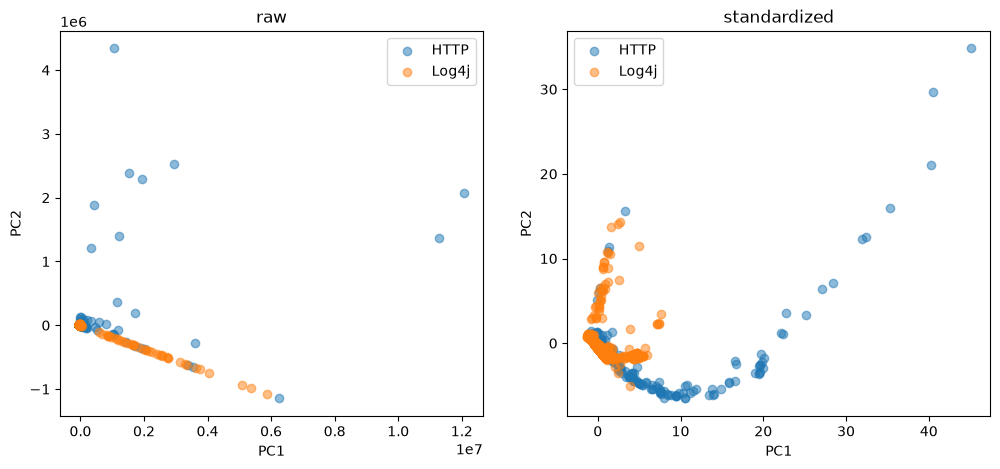

In [33]:
# Project onto the top two components, with and without scaling
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
projections = [(axes[0], pca_raw.transform(X), 'raw'),
               (axes[1], pca_scaled.transform(X_scaled), 'standardized')]

for ax, proj, title in projections:
    for label, name in [(0, 'HTTP'), (1, 'Log4j')]:
        ax.scatter(proj[y == label, 0], proj[y == label, 1], alpha=0.5, label=name)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()

After standardizing, the variance is spread across many more components: PC1 explains about 42%, and it takes 5 components to reach 90%. PC1 is now a mix of the packet-size statistics rather than a single large-magnitude column. This is a more honest picture of how much the feature set can actually be compressed.

When you evaluate a lower-dimensional model below, fit the scaler and PCA on the training data only, e.g. by putting `StandardScaler` → `PCA` → classifier in a `Pipeline` and cross-validating the whole pipeline, so information from the test folds doesn't leak into the transformation.

### Evaluate the Lower Dimension Model

Evaluate the accuracy of the lower dimensionality model trained on the random forest classifier in the same fashion as above. What happens to the accuracy? Why?

What might be a good reason to reduce the dimensionality of the dataset?